```
Hiểu:
- Stride là gì
- Kernel di chuyển như thế nào
- Stride ảnh hưởng tới Output Shape
- Tại sao Stride giúp giảm kích thước Feature Map
```

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.convolution import Convolution2D
from src.utils import (
    load_image,
    show_image
)

In [2]:
print("=" * 60)
print("CNN FROM SCRATCH")
print("04 - STRIDE")
print("=" * 60)

CNN FROM SCRATCH
04 - STRIDE


In [3]:
print("""
Stride controls
how far the kernel moves
at every step.

Stride = 1
move 1 pixel

Stride = 2
move 2 pixels

Stride = 3
move 3 pixels
""")


Stride controls
how far the kernel moves
at every step.

Stride = 1
move 1 pixel

Stride = 2
move 2 pixels

Stride = 3
move 3 pixels



part 1 - Visual Understanding

In [4]:
image = np.arange(
    25
).reshape(5,5)

print(image)

[[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]
 [15 16 17 18 19]
 [20 21 22 23 24]]


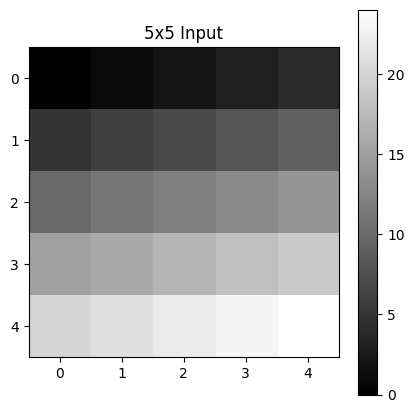

In [5]:
plt.figure(figsize=(5,5))

plt.imshow(
    image,
    cmap="gray"
)

plt.title(
    "5x5 Input"
)

plt.colorbar()

plt.show()

Part 2 - Stride = 1

In [6]:
print("""
Kernel Size = 3

Stride = 1

Positions:

(0,0)
(0,1)
(0,2)

(1,0)
(1,1)
(1,2)

(2,0)
(2,1)
(2,2)
""")


Kernel Size = 3

Stride = 1

Positions:

(0,0)
(0,1)
(0,2)

(1,0)
(1,1)
(1,2)

(2,0)
(2,1)
(2,2)



In [7]:
H = 5
K = 3
S = 1
P = 0

H_out = (
    (H-K+2*P)//S
) + 1

print(
    "Output Height:",
    H_out
)

Output Height: 3


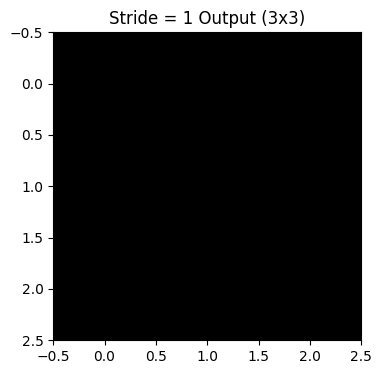

In [8]:
output_stride1 = np.zeros(
    (3,3)
)

plt.figure(figsize=(4,4))

plt.imshow(
    output_stride1,
    cmap="gray"
)

plt.title(
    "Stride = 1 Output (3x3)"
)

plt.show()

Part 3 - Stride = 2

In [9]:
print("""
Kernel Positions

(0,0)
(0,2)

(2,0)
(2,2)

Kernel jumps
2 pixels each step.
""")


Kernel Positions

(0,0)
(0,2)

(2,0)
(2,2)

Kernel jumps
2 pixels each step.



In [10]:
H = 5
K = 3
S = 2
P = 0

H_out = (
    (H-K+2*P)//S
) + 1

print(
    "Output Height:",
    H_out
)

Output Height: 2


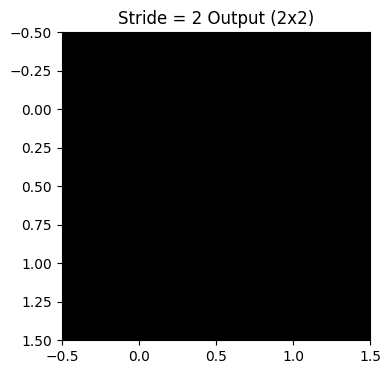

In [11]:
output_stride2 = np.zeros(
    (2,2)
)

plt.figure(figsize=(4,4))

plt.imshow(
    output_stride2,
    cmap="gray"
)

plt.title(
    "Stride = 2 Output (2x2)"
)

plt.show()

Part 4 output shape Formula

In [12]:
print("""
Output Formula

Hout =
((H-K+2P)//S)+1

Wout =
((W-K+2P)//S)+1
""")


Output Formula

Hout =
((H-K+2P)//S)+1

Wout =
((W-K+2P)//S)+1



In [13]:
examples = [
    (5,3,1,0),
    (5,3,2,0),
    (28,3,1,1),
    (28,3,2,1)
]

for H,K,S,P in examples:

    H_out = (
        (H-K+2*P)//S
    ) + 1

    print(
        f"H={H}, K={K}, S={S}, P={P}"
    )

    print(
        f"Output={H_out}"
    )

    print("-"*30)

H=5, K=3, S=1, P=0
Output=3
------------------------------
H=5, K=3, S=2, P=0
Output=2
------------------------------
H=28, K=3, S=1, P=1
Output=28
------------------------------
H=28, K=3, S=2, P=1
Output=14
------------------------------


Part 5 - Real Convolution

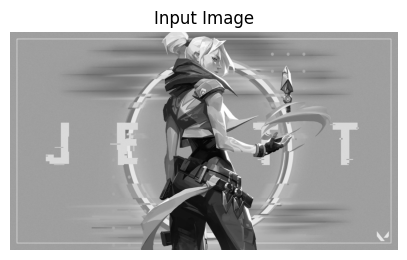

In [14]:
image = load_image(
    "../data/sample.jpg",
    grayscale=True
)

show_image(
    image,
    "Input Image"
)

In [15]:
# Stride = 1

conv_stride1 = Convolution2D(
    in_channels=1,
    out_channels=1,
    kernel_size=3,
    stride=1,
    padding=1
)

feature_map1 = (
    conv_stride1.forward(image)
)

print(
    feature_map1.shape
)

(1, 1080, 1920)


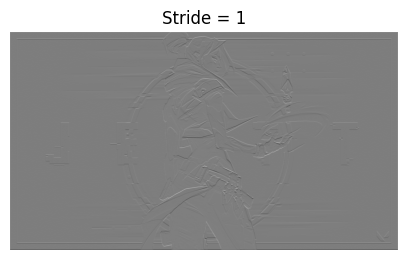

In [16]:
show_image(
    feature_map1,
    "Stride = 1"
)

In [17]:
# Stride = 2

conv_stride2 = Convolution2D(
    in_channels=1,
    out_channels=1,
    kernel_size=3,
    stride=2,
    padding=1
)

feature_map2 = (
    conv_stride2.forward(image)
)

print(
    feature_map2.shape
)

(1, 540, 960)


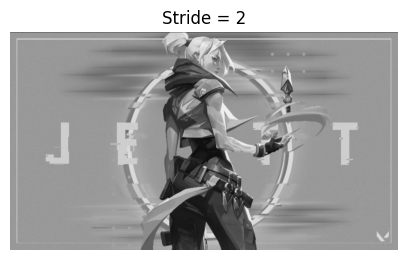

In [18]:
show_image(
    feature_map2,
    "Stride = 2"
)

Part 6 - Compare

In [19]:
print(
    "Input:",
    image.shape
)

print(
    "Stride 1:",
    feature_map1.shape
)

print(
    "Stride 2:",
    feature_map2.shape
)

Input: (1, 1080, 1920)
Stride 1: (1, 1080, 1920)
Stride 2: (1, 540, 960)


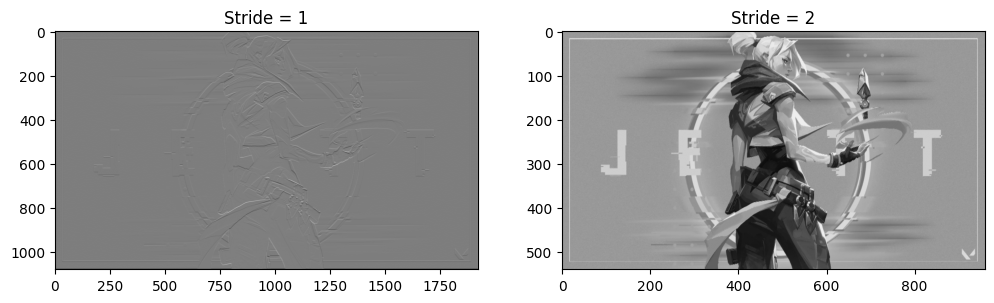

In [20]:
fig, ax = plt.subplots(
    1,
    2,
    figsize=(12,5)
)

ax[0].imshow(
    feature_map1[0],
    cmap="gray"
)

ax[0].set_title(
    "Stride = 1"
)

ax[1].imshow(
    feature_map2[0],
    cmap="gray"
)

ax[1].set_title(
    "Stride = 2"
)

plt.show()

CNN Perspective

```
Why use larger strides?

Advantages

✓ Smaller feature maps

✓ Faster computation

✓ Less memory

✓ Larger receptive field

Disadvantages

✗ Lose spatial details

✗ Can miss small patterns
```

```
LeNet:
Mostly Stride=1

VGG:
Stride=1

ResNet:
Stride=2 when downsampling

CNN Rule:

Feature Extraction
→ Stride=1

Downsampling
→ Stride=2
```
